# Resources

- [Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/)

## What to expect today

  Learn basic scientific `python` tools including

  - numeric arrays (everything is a number!)
  - tabular data manipulation
  - data visualization

## Installation issues

Make sure you have `Python`, `numpy`, `pandas`, and `seaborn` installed. 

# Are `python` list not enough?

From yesterday:

In [145]:
numbers = [1.0, 2.0, 3]
numbers

[1.0, 2.0, 3]

# Are `python` lists not enough?

In [146]:
python_list = ["a", 1, 1.5]
for elm in python_list:
    eltype = type(elm)
    print(elm, "->", eltype)

a -> <class 'str'>
1 -> <class 'int'>
1.5 -> <class 'float'>


# Introduction to NumPy

_Storage and manipulation of numerical arrays are essential data science tasks_

In [147]:
# By convention!
import numpy as np

## NumPy Array

In [148]:
vector = np.array([0, 1, 2, 3])

print("vector ndim: ", vector.ndim)
print("vector shape:", vector.shape)
print("vector size: ", vector.size)

vector ndim:  1
vector shape: (4,)
vector size:  4


In [149]:
matrix = np.array([[1, 2], [3, 4]])
print("matrix ndim: ", matrix.ndim)
print("matrix shape:", matrix.shape)
print("matrix size: ", matrix.size)

matrix ndim:  2
matrix shape: (2, 2)
matrix size:  4


# Indexing 1-D NumPy arrays

In [150]:
vector = np.array([0, 1, 2, 3])
print(vector[0]) # Access the ith value (counting from zero)
print(vector[-1]) # Index from the end of the array, you can use negative indices:

0
3


# Indexing 2-D NumPy arrays

In [151]:
matrix = np.array([[1, 2], [3, 4]])
print(matrix[0]) # Access the ith row (counting from zero)
print(matrix[0, 0]) # Access the ith row, jth column (counting from zero)
print(matrix[:, 0]) # Access all rows of the ith column)
matrix[0:1] = 1 # Assign the value 1 to the [0, 1) row

[1 2]
1
[1 3]


# Reshaping of arrays

In [152]:
grid_long = np.arange(1, 10) # All indexes from [1, 10)
grid = grid_long.reshape((3, 3)) # 3x3 matrix
grid

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

# Reshaping of arrays

Question: Can you convert grid into a "long" format again? 

In [153]:
grid_long2 = grid
#assert grid_long2.shape == grid_long.shape

Hint: [Python For Data Science Cheat Sheet](resources/Numpy_Python_Cheat_Sheet.pdf)

## Concatenation of arays

In [154]:
x = np.array([1, 2, 3])
y = np.array([3, 2, 1])
np.concatenate([x, y])

array([1, 2, 3, 3, 2, 1])

## Aside: Randonness in `Python `

![From the `A Million Random Digits with 100,000 Normal Deviates`](resources/Random_digits.png)


## Aside: Randomness in `Python`

  Random number generation is fundamental in science! Best
  practices include being _explicit_ and _exhaustive_

In [155]:
seed = 312657 # 
size = 10_000_000
rng = np.random.default_rng(seed)
x_array = rng.normal(0, 1, size)

## Computations on NumPy arrays

Why not use Python `for` loops?

In [156]:
def naive_mean_x2(values):
    "Compute mean(x^2) as (sum_0^N x[i]^2) / N"
    return sum(val **2 for val in values) / len(values)

## Computations on NumPy arrays

In [157]:
x_list= [float(x) for x in x_array]

In [158]:
%%time
naive_mean_x2(x_list)

CPU times: user 827 ms, sys: 3.59 ms, total: 830 ms
Wall time: 936 ms


0.9998914024882065

## Computations on NumPy arrays

  When possible, use existing functions from libraries such
   as `scipy` or `numpy`. Functions from existing packages
  will be

  1. faster
  2. more accurate (numerical precision)
  3. less error-prone

In [159]:
%%time
np.mean(x_array**2)

CPU times: user 7.32 ms, sys: 22.9 ms, total: 30.2 ms
Wall time: 34.5 ms


np.float64(0.9998914024882065)

# Exercise: Punctuality Belgian trains

  I've gathered the mean delayed time (in minutes) of all
  domestic and international trains in Belgium per day
  during 2025.

  1. Read the dataset from
  `datasets/belgian_train_punctuality.txt`
  2. Compute the average (of the average) of January,
  February and June.
  3. Can you compute the average _per_ day (e.g. Monday?)

  Hint: [Python For Data Science Cheat
  Sheet](resources/Numpy_Python_Cheat_Sheet.pdf)

# Exercise: Punctuality Belgian trains

Bonus: Are you done?

Look at and see how I made the dataset. Can you identify good practices (or bad ones!)?

[datasets/belgian_train_puntuality.py](datasets/belgian_train_puntuality.py)

## Other useful operations

- Min., Max.
- argmax, argmin
- quantile

In [160]:
delay_minutes = np.loadtxt("datasets/belgian_train_punctuality.txt")
np.min(delay_minutes), np.max(delay_minutes)

(np.float64(0.8043181545476361), np.float64(4.467847200169365))

In [161]:
np.argmin(delay_minutes), np.argmax(delay_minutes)

(np.int64(358), np.int64(218))

In [162]:
np.quantile(delay_minutes, [0.1, 0.5, 0.9])

array([1.29655604, 1.8347351 , 2.62319279])

# Data Manipulation

> DataFrames are enhanced versions of NumPy structured arrays in which the rows and columns are identified with labels rather than simple integer indices

In [163]:
import pandas as pd # Convention!

## Series

One-dimensional array of indexed data

In [164]:
indexed_array = pd.Series([0.25, 0.5, 0.75, 1.0, -0.1], index=['monday', 'tuesday', 'wednesday', 'thursday', 'friday'])
indexed_array['monday']

np.float64(0.25)

## Indexing alignment


In [165]:
area = pd.Series({'Alaska': 1723337, 'Texas': 695662, 'California': 423967}, name='area')
population = pd.Series({'California': 38332521, 'Texas': 26448193, 'New York': 19651127}, name='population')

population / area


Alaska              NaN
California    90.413926
New York            NaN
Texas         38.018740
dtype: float64

## Indexing alignment

_Devil's advocate_: I can do this in a `Spreadsheet`!

Yes, but ...

In [166]:
area = pd.Series({'Alaska': 1723337, 'Texas': 695662, 'California': 423967}, name='area')
population = pd.Series({'California': 38332521, 'Texas': 26448193, 'New York': 19651127}, name='population')

population / area

Alaska              NaN
California    90.413926
New York            NaN
Texas         38.018740
dtype: float64

## DataFrame

In [167]:
population_dict = {'California': 38332521,
                   'Texas': 26448193,
                   'New York': 19651127,
                   'Florida': 19552860,
                   'Illinois': 12882135}
population = pd.Series(population_dict)
area_dict = {'California': 423967, 'Texas': 695662, 'New York': 141297,
             'Florida': 170312, 'Illinois': 149995}
area = pd.Series(area_dict)
states = pd.DataFrame({'population': population,'area': area})
states

,population,area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


## Indexing a DataFrame

In [168]:
states["area"] # the `area` column 
states["area"]["California"]  # the `area` column  at the `California row`
states.loc["California"] # The `california row`
states.iloc[1] # The i-th row
states["area"].iloc[2] # The area of the i-th row

np.int64(141297)

## Reading DataFrames from CSVs



## Penguins dataset

![](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)

## Reading DataFrames

In [169]:
df_penguin = pd.read_csv("datasets/penguins.csv")
df_penguin.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


## Explore the dataset

Try using the `.describe()` method!


## Explore the dataset

![Penguin dataset](https://allisonhorst.github.io/palmerpenguins/reference/figures/culmen_depth.png)

## Handling Missing Data

  - Raw python uses `None`
  - But `numpy` and `pandas` use `NaN` (acronym for Not a
  Number)

  `NaN` values have special arithmetics!

In [170]:
vec_with_nan = np.array([1.2, 0.2, np.nan])
1 + np.nan, 0 *  np.nan, np.min(vec_with_nan)

(nan, nan, np.float64(nan))

## Exercise

1. Compute the average `bill_length_mm` in the penguins dataset. 
2. Count how many `NaN` observations there are in the dataset.
3. Define a new dataset without `NaN` values (hint: use the `dropna` method)

In [171]:
# Compute the average `bill_length_mm`
df_penguin["bill_depth_mm"].mean()
bill_depth_mm = df_penguin["bill_depth_mm"].to_numpy()
np.mean(bill_depth_mm), np.nanmean(bill_depth_mm)

df_penguin_filtered = df_penguin.dropna()
df_penguin.shape[0] - df_penguin_filtered.shape[0]

11

## Masking operations

In [172]:
mask = (df_penguin.island=="Torgersen") & (df_penguin.sex=="FEMALE")
df_penguin[mask]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,FEMALE
12,Adelie,Torgersen,41.1,17.6,182.0,3200.0,FEMALE
15,Adelie,Torgersen,36.6,17.8,185.0,3700.0,FEMALE
16,Adelie,Torgersen,38.7,19.0,195.0,3450.0,FEMALE
18,Adelie,Torgersen,34.4,18.4,184.0,3325.0,FEMALE
68,Adelie,Torgersen,35.9,16.6,190.0,3050.0,FEMALE
70,Adelie,Torgersen,33.5,19.0,190.0,3600.0,FEMALE


## Combining datasets

In [173]:
df1 = pd.DataFrame(dict(
    tank = ["A", "B", "C", "D"],
    experiment = ["growth", "hybrid", None, None]
))
df2 = pd.DataFrame(dict(
    fish_id = np.arange(1000),
    tank = rng.choice(["A", "B", "C", "D"], 1000)
))
(df1.head(), df2.head())

(  tank experiment
 0    A     growth
 1    B     hybrid
 2    C        NaN
 3    D        NaN,
    fish_id tank
 0        0    C
 1        1    A
 2        2    D
 3        3    C
 4        4    B)

## Combining datasets

Other types of joins you may find when you have duplicated entries

- many-to-one
- and many-to-many

In [174]:
df_merged = pd.merge(df2, df1)
df_merged

,fish_id,tank,experiment
0,0,C,NaN
1,1,A,growth
2,2,D,NaN
3,3,C,NaN
4,4,B,hybrid
...,...,...,...
995,995,B,hybrid
996,996,C,NaN
997,997,B,hybrid
998,998,C,NaN


## Aggregation and Grouping

![](https://jakevdp.github.io/PythonDataScienceHandbook/figures/03.08-split-apply-combine.png)

## Group-by operator

  Rather than doing it manually, we can avoid the
  intermediate splits using `df.groupby`.

In [175]:
df_penguin_filtered.groupby('species')['flipper_length_mm'].mean()

species
Adelie       190.102740
Chinstrap    195.823529
Gentoo       217.235294
Name: flipper_length_mm, dtype: float64

Question: Can you compute the mean `flipper_length_mm` per species and sex?

## Group-by operator


In [176]:
df_penguin_filtered.groupby(['species', 'sex'])['flipper_length_mm'].mean()

species    sex   
Adelie     FEMALE    187.794521
           MALE      192.410959
Chinstrap  FEMALE    191.735294
           MALE      199.911765
Gentoo     FEMALE    212.706897
           MALE      221.540984
Name: flipper_length_mm, dtype: float64

## Visualization with `Matplotlib` and `Seaborn`

Are you coming from `R`? Check [https://plotnine.org](https://plotnine.org)


In [177]:
import matplotlib.pyplot as plt # The worst convention

## The basics

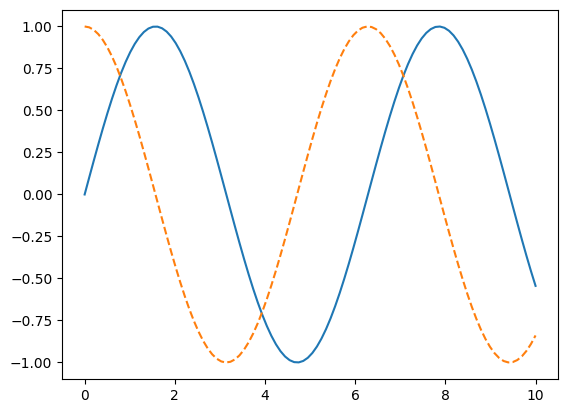

In [178]:
import numpy as np
x = np.linspace(0, 10, 100)

fig = plt.figure()
plt.plot(x, np.sin(x), '-')
plt.plot(x, np.cos(x), '--');

## Histograms

(array([ 8., 39., 55., 47., 47., 53., 61., 16.,  5.,  2.]),
 array([32.1 , 34.85, 37.6 , 40.35, 43.1 , 45.85, 48.6 , 51.35, 54.1 ,
        56.85, 59.6 ]),
 <BarContainer object of 10 artists>)

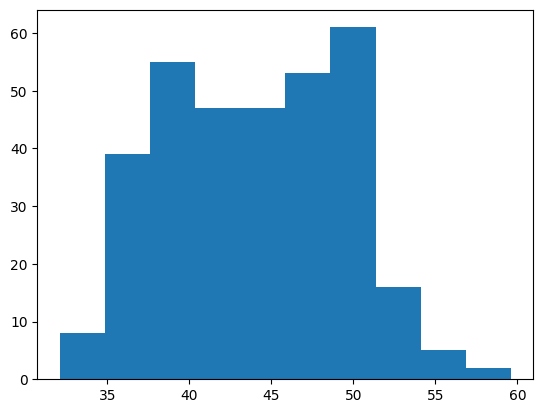

In [179]:
plt.hist(df_penguin_filtered['bill_length_mm'])

# Anatomy of a figure

# 

![](https://matplotlib.org/stable/_images/anatomy.png)

## Step-by-step plot

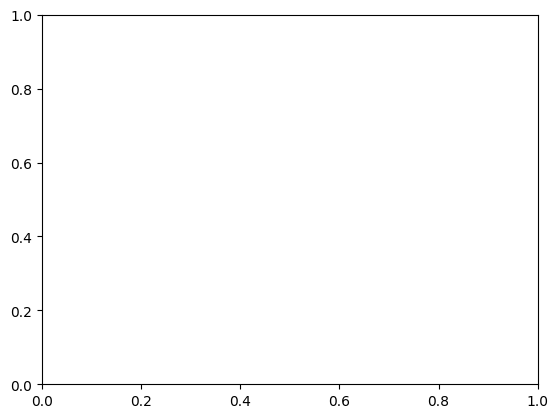

In [180]:
fig, ax = plt.subplots()

## Step-by-step plot

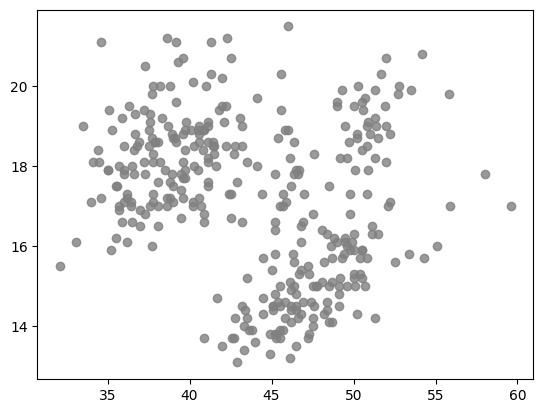

In [181]:
fig, ax = plt.subplots()
ax.plot('bill_length_mm', 'bill_depth_mm', 'o',  markeredgewidth=1, alpha = 0.8, color = "grey", data=df_penguin)

## Step-by-step plot

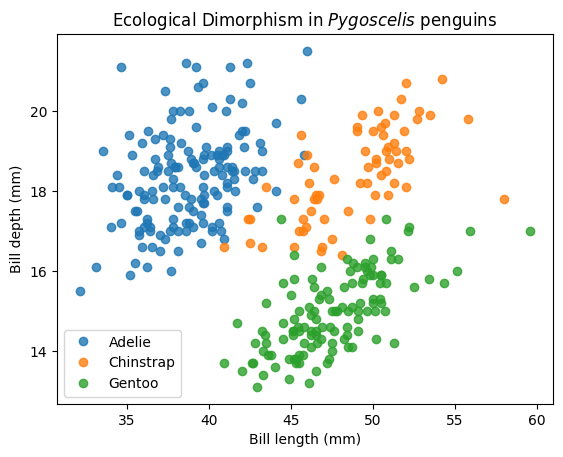

In [182]:
#| output-location: slide

fig, ax = plt.subplots()

for species, df_subset in df_penguin.groupby('species'):
    ax.plot('bill_length_mm', 'bill_depth_mm', 'o',  markeredgewidth=1, alpha = 0.8, data=df_subset, label = species)

plt.legend()
ax.set_ylabel("Bill depth (mm)")
ax.set_xlabel("Bill length (mm)")
ax.set_title("Ecological Dimorphism in $\\it{Pygoscelis}$ penguins")
plt.show()

## Exercise: let's make final quality plots

  1. Skim through [Ten Simple Rules for Better Figures](https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1003833)
  2. Prepare a plot where we can visualize _both_ species and sex (doesn't have to be a scatterplot!)
  3. Adjust the plot until satisfied _as_ if you were making this plot for a publication / talk / poster.

  Need inspiration? Read into
  https://matplotlib.org/cheatsheets/

# Statistical data visualization

`Seaborn`: many built-in visualizations!

In [183]:
import seaborn as sns

# Overview of `seaborn` 

![](https://seaborn.pydata.org/_images/function_overview_8_0.png)

## Overview of `seaborn` 


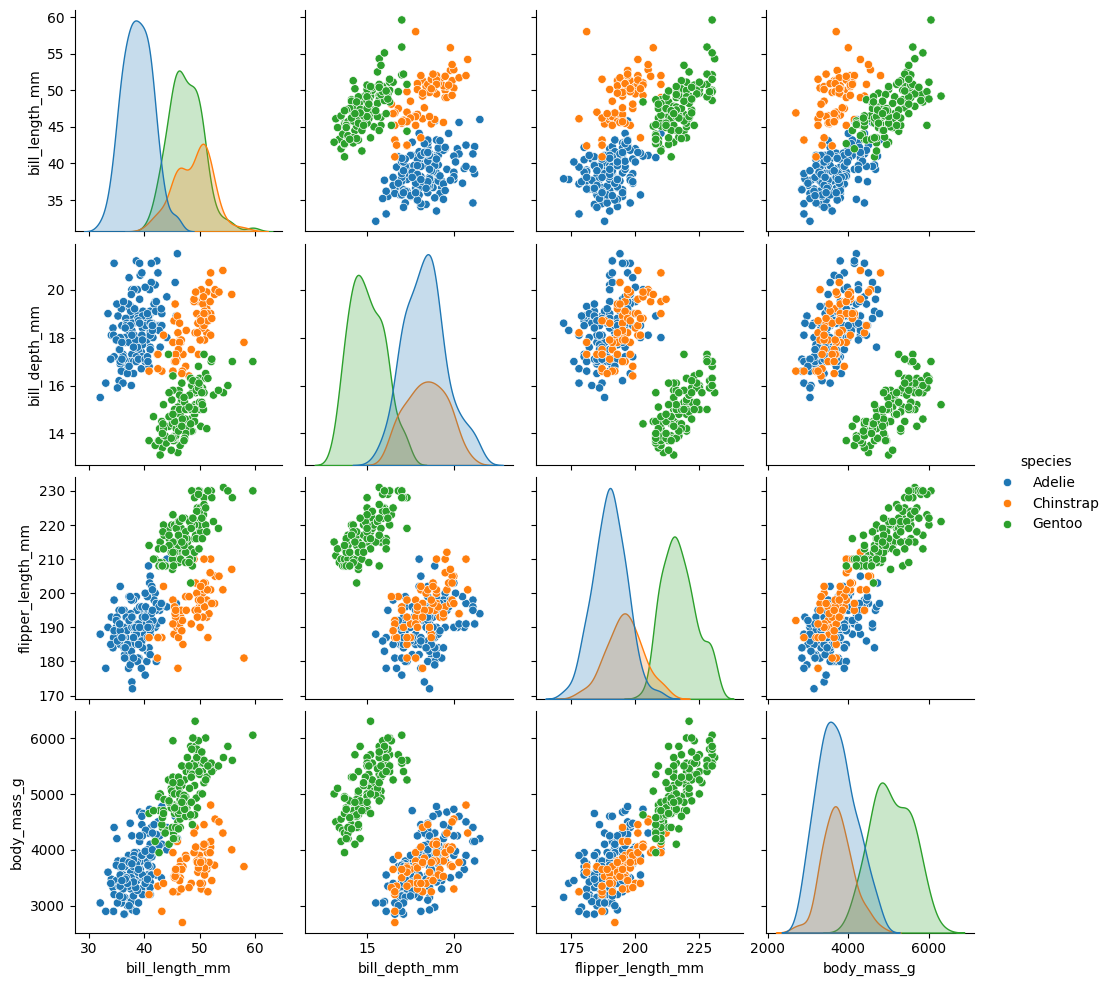

In [184]:
sns.pairplot(data=df_penguin, hue="species")

## Exercise

Boxplots (or box-and-whisker plots) condense many information.

Question: read the `seaborn` documentation and find exactly what each element in the figure means

## Exercise

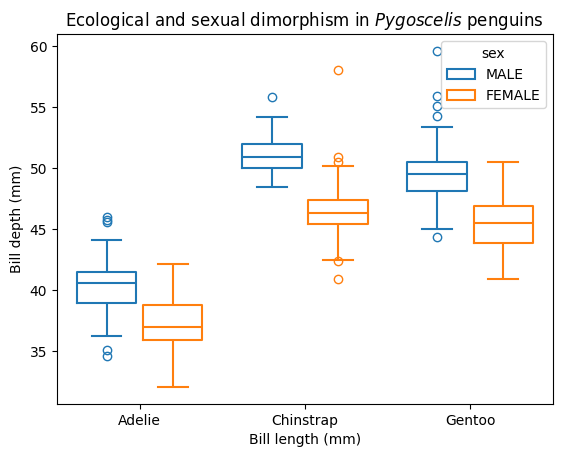

In [185]:
#| output-location: slide
fig, ax = plt.subplots()
sns.boxplot(
    x="species", y="bill_length_mm", hue="sex",
    fill=False, gap=.1, data=df_penguin,
)
ax.set_ylabel("Bill depth (mm)")
ax.set_xlabel("Bill length (mm)")
ax.set_title("Ecological and sexual dimorphism in $\\it{Pygoscelis}$ penguins")
plt.show()

## Fit and visualize regression models

Question: read the `seaborn` documentation and find exactly what each element in the figure means

Tip: for final analysis you want to use a specialized library such `statsmodels`.

## Fit and visualize regression models

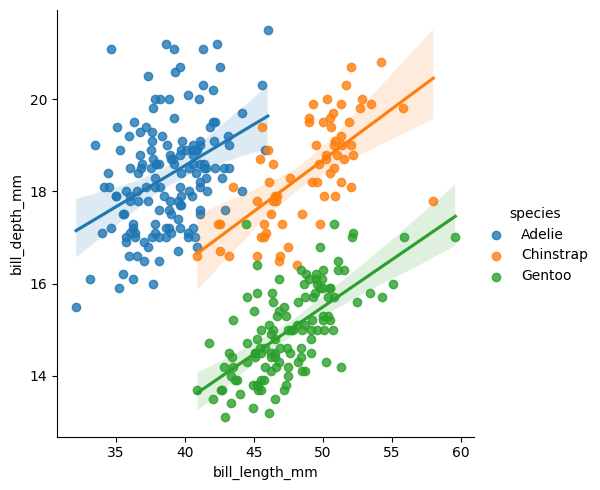

In [186]:
#| output-location: slide
sns.lmplot(
    x="bill_length_mm", y="bill_depth_mm", hue="species",
    data=df_penguin, ci=99, n_boot=1_000, seed=3817
)

## Bonus: heatmap

Distance matrices are more naturally visualized as heatmaps: 

In [187]:
# Phylogenetic distances across different primate species
primates_distance = pd.read_csv("datasets/Primates301_distance_matrix.csv", index_col=0)
primates_distance.head()

,Allenopithecus_nigroviridis,Cercopithecus_albogularis,Cercopithecus_ascanius,Cercopithecus_campbelli,Cercopithecus_campbelli_lowei,Cercopithecus_cephus,Cercopithecus_cephus_cephus,Cercopithecus_cephus_ngottoensis,Cercopithecus_diana,Cercopithecus_erythrogaster,...,Galago_moholi,Galago_senegalensis,Galagoides_demidoff,Galagoides_zanzibaricus,Otolemur_crassicaudatus,Otolemur_garnettii,Tarsius_bancanus,Tarsius_dentatus,Tarsius_lariang,Tarsius_syrichta
Allenopithecus_nigroviridis,0.000000,23.789805,23.789805,23.789804,23.789804,23.789806,23.789806,23.789806,23.789804,23.789805,...,146.006037,146.006037,146.006036,146.006036,146.006037,146.006037,137.680065,137.680065,137.680065,137.680065
Cercopithecus_albogularis,23.789805,0.000000,12.858418,15.780435,15.780435,12.858419,12.858419,12.858419,15.780435,12.858418,...,146.006038,146.006038,146.006037,146.006037,146.006038,146.006038,137.680066,137.680066,137.680066,137.680066
Cercopithecus_ascanius,23.789805,12.858418,0.000000,15.780435,15.780435,4.037887,4.037887,4.037887,15.780435,5.463272,...,146.006038,146.006038,146.006037,146.006037,146.006038,146.006038,137.680066,137.680066,137.680066,137.680066
Cercopithecus_campbelli,23.789804,15.780435,15.780435,0.000000,0.548556,15.780436,15.780436,15.780436,11.974562,15.780435,...,146.006037,146.006037,146.006036,146.006036,146.006037,146.006037,137.680065,137.680065,137.680065,137.680065
Cercopithecus_campbelli_lowei,23.789804,15.780435,15.780435,0.548556,0.000000,15.780436,15.780436,15.780436,11.974562,15.780435,...,146.006037,146.006037,146.006036,146.006036,146.006037,146.006037,137.680065,137.680065,137.680065,137.680065


## Bonus: heatmap

<Axes: >

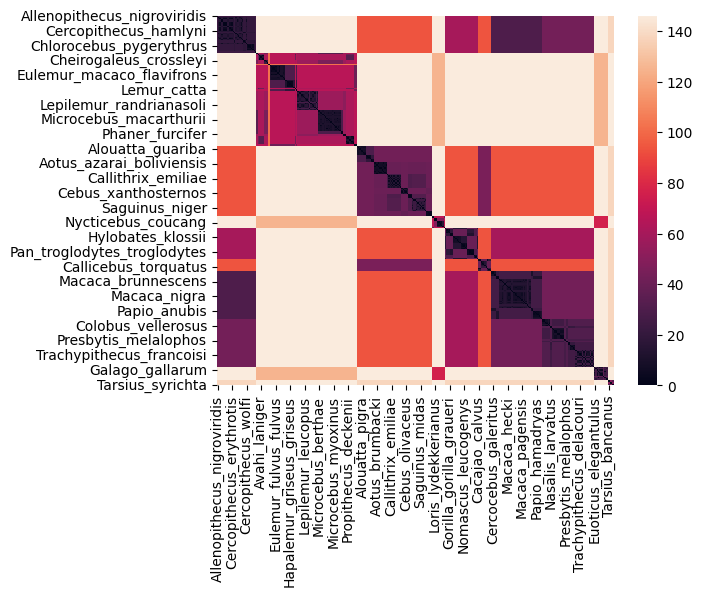

In [188]:
sns.heatmap(primates_distance)

## Group exercise

For the rest of this session, we will: 

1. Analyse one dataset in groups
2. Create a single figure that clearly communicates one key finding or pattern
3. Be ready to present (<5 minutes) the figure you made and how you made it (guide us through your code!)

## Example

![](resources/tidytuesday_example.png)

## Datasets

1. Japan Cherry Blossom Historical Data
2. Hurricane fatalities and gender of names
3. Chimpanzees cracking panda nuts
4. Primate life history and social learning data
5. Average heterozygosity across bird populations
6. Or bring your own!


Notes: I removed references. I want to know if you arrive at the same conclusions as the original authors!

## Presentation time!